# 🛰️ Adaptive Machine Learning Based Wireless Channel Intelligence

**Dataset:** ASU Campus 3.5 GHz (DeepMIMO)  
**Carrier:** 3.5 GHz | **BW:** 100 MHz | **Ray Tracer:** Remcom Wireless InSite 3.3  
**Tasks:** Beam Prediction · RSS Estimation · LOS Detection · Channel Autoencoder

---

## Section 1 — Environment Setup & Imports


In [1]:
import sys, os, json, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '../')  # Add project root

import numpy as np
import scipy.io as sio
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm

# ML libraries
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score, ConfusionMatrixDisplay
)
import joblib

# ── Dark plot style ──────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0a0d1a',
    'axes.facecolor': '#111827',
    'axes.edgecolor': '#2d3748',
    'axes.labelcolor': '#e2e8f0',
    'xtick.color': '#94a3b8',
    'ytick.color': '#94a3b8',
    'text.color': '#e2e8f0',
    'grid.color': '#1e293b',
    'grid.linestyle': '--',
    'grid.alpha': 0.7,
    'font.family': 'sans-serif',
    'font.size': 11,
})

CYAN, PURPLE, GREEN, ORANGE = '#00d4ff', '#a855f7', '#22c55e', '#f97316'

print('✓ All libraries imported successfully')
import sklearn
print(f'  NumPy: {np.__version__},  sklearn: {sklearn.__version__}')


✓ All libraries imported successfully
  NumPy: 2.2.6,  sklearn: 1.9.0


---
## Section 2 — DeepMIMO Data Loading


In [2]:
# ─── CONSTANTS ──────────────────────────────────────────────
candidates = [Path('deepmimo_scenarios/asu_campus_3p5'), Path('../deepmimo_scenarios/asu_campus_3p5')]
SCENARIO_PATH = next((c for c in candidates if c.exists()), Path('deepmimo_scenarios/asu_campus_3p5'))
CARRIER_FREQ  = 3.5e9       # Hz
WAVELENGTH    = 3e8 / CARRIER_FREQ  # ~0.0857 m
N_BEAMS       = 64          # DFT codebook size
MAX_POINTS    = 10000       # Subset for fast dev; set None for all 85K

print(f'Scenario path: {SCENARIO_PATH.resolve()}')
print(f'Path exists:   {SCENARIO_PATH.exists()}')
print(f'Files found:   {len(list(SCENARIO_PATH.glob("*.mat")))} .mat files')

# Load scenario parameters
with open(SCENARIO_PATH / 'params.json') as f:
    params = json.load(f)

rt = params['rt_params']
print(f"\n=== Scenario: ASU Campus 3.5 GHz ===")
print(f"  Frequency:       {rt['frequency']/1e9:.1f} GHz")
print(f"  Bandwidth:       100 MHz")
print(f"  Max Path Depth:  {rt['max_path_depth']}")
print(f"  Max Reflections: {rt['max_reflections']}")
print(f"  Num Rays:        {rt['num_rays']:,}")
txrx = params['txrx_sets']
n_ue = txrx['txrx_set_0']['num_active_points']
print(f"  Active UE Pts:   {n_ue:,}")


Scenario path: C:\Users\HP\OneDrive\Desktop\Adaptive ML\deepmimo_scenarios\asu_campus_3p5
Path exists:   True
Files found:   23 .mat files

=== Scenario: ASU Campus 3.5 GHz ===
  Frequency:       3.5 GHz
  Bandwidth:       100 MHz
  Max Path Depth:  7
  Max Reflections: 6
  Num Rays:        259,200
  Active UE Pts:   85,157


In [3]:
def load_mat(filename):
    """Load a .mat file and return the primary array variable."""
    path = SCENARIO_PATH / filename
    if not path.exists():
        print(f'  [WARN] Not found: {filename}')
        return None
    mat = sio.loadmat(str(path))
    keys = [k for k in mat.keys() if not k.startswith('_')]
    return mat[keys[0]] if keys else None

print('Loading .mat files...')
rx_pos = load_mat('rx_pos_t001_tx000_r000.mat')  # (N, 3) UE positions [x,y,z]
tx_pos = load_mat('tx_pos_t001_tx000_r000.mat')  # (1, 3) BS position
power  = load_mat('power_t001_tx000_r000.mat')   # (N, P) path power dB
phase  = load_mat('phase_t001_tx000_r000.mat')   # (N, P) path phase rad
delay  = load_mat('delay_t001_tx000_r000.mat')   # (N, P) path delay s
aoa_az = load_mat('aoa_az_t001_tx000_r000.mat')  # (N, P) AoA azimuth deg
aoa_el = load_mat('aoa_el_t001_tx000_r000.mat')  # (N, P) AoA elevation deg
aod_az = load_mat('aod_az_t001_tx000_r000.mat')  # (N, P) AoD azimuth deg
aod_el = load_mat('aod_el_t001_tx000_r000.mat')  # (N, P) AoD elevation deg
inter  = load_mat('inter_t001_tx000_r000.mat')   # (N, P) interaction type

N_total = rx_pos.shape[0]
print(f'\n✓ Loaded {N_total:,} UE points')
print(f'  rx_pos shape: {rx_pos.shape}  |  power shape: {power.shape}')
print(f'  tx_pos (BS):  {tx_pos}')

# Optional subset for faster development
if MAX_POINTS and N_total > MAX_POINTS:
    rng = np.random.RandomState(42)
    idx = np.sort(rng.choice(N_total, MAX_POINTS, replace=False))
    rx_pos, power, phase, delay = rx_pos[idx], power[idx], phase[idx], delay[idx]
    aoa_az, aoa_el = aoa_az[idx], aoa_el[idx]
    aod_az, aod_el = aod_az[idx], aod_el[idx]
    inter = inter[idx]
    N = MAX_POINTS
    print(f'  Subsetted to {N:,} points (RandomState seed=42)')
else:
    N = N_total

if tx_pos.ndim == 2:
    tx_pos = tx_pos[0]  # flatten to (3,)


Loading .mat files...

✓ Loaded 131,931 UE points
  rx_pos shape: (131931, 3)  |  power shape: (131931, 10)
  tx_pos (BS):  [[166. 104.  22.]]
  Subsetted to 10,000 points (RandomState seed=42)


---
## Section 3 — Exploratory Data Analysis (EDA)


In [4]:
# ─── Preprocessing ──────────────────────────────────────────
noise_floor = -250.0
valid_mask  = (power != 0) & (~np.isnan(power))  # True where path exists
n_paths_ue  = valid_mask.sum(axis=1)              # paths per UE
power_db    = np.where(valid_mask, power, noise_floor)  # fill invalid with floor
power_lin   = 10 ** (power_db / 10.0)            # convert to linear

dist_3d = np.linalg.norm(rx_pos - tx_pos, axis=1)
dist_2d = np.linalg.norm(rx_pos[:, :2] - tx_pos[:2], axis=1)

print('='*55)
print('  Dataset Summary Statistics')
print('='*55)
print(f'  Total UE Points:      {N:,}')
print(f'  Coverage (paths > 0): {(n_paths_ue > 0).mean()*100:.1f}%')
print(f'  Avg paths / UE:       {n_paths_ue.mean():.2f}')
print(f'  Max paths / UE:       {n_paths_ue.max()}')
print(f'  3D Distance range:    {dist_3d.min():.1f} -- {dist_3d.max():.1f} m')
dom_pow_valid = power_db[:, 0][power_db[:, 0] > noise_floor + 10]
print(f'  Dominant power:       {dom_pow_valid.min():.1f} to {dom_pow_valid.max():.1f} dB')
print(f'  UE height range:      {rx_pos[:,2].min():.1f} -- {rx_pos[:,2].max():.1f} m')


  Dataset Summary Statistics
  Total UE Points:      10,000
  Coverage (paths > 0): 64.4%
  Avg paths / UE:       6.19
  Max paths / UE:       10
  3D Distance range:    20.7 -- 472.8 m
  Dominant power:       -178.1 to -71.5 dB
  UE height range:      1.5 -- 1.5 m


Saved: eda_overview.png


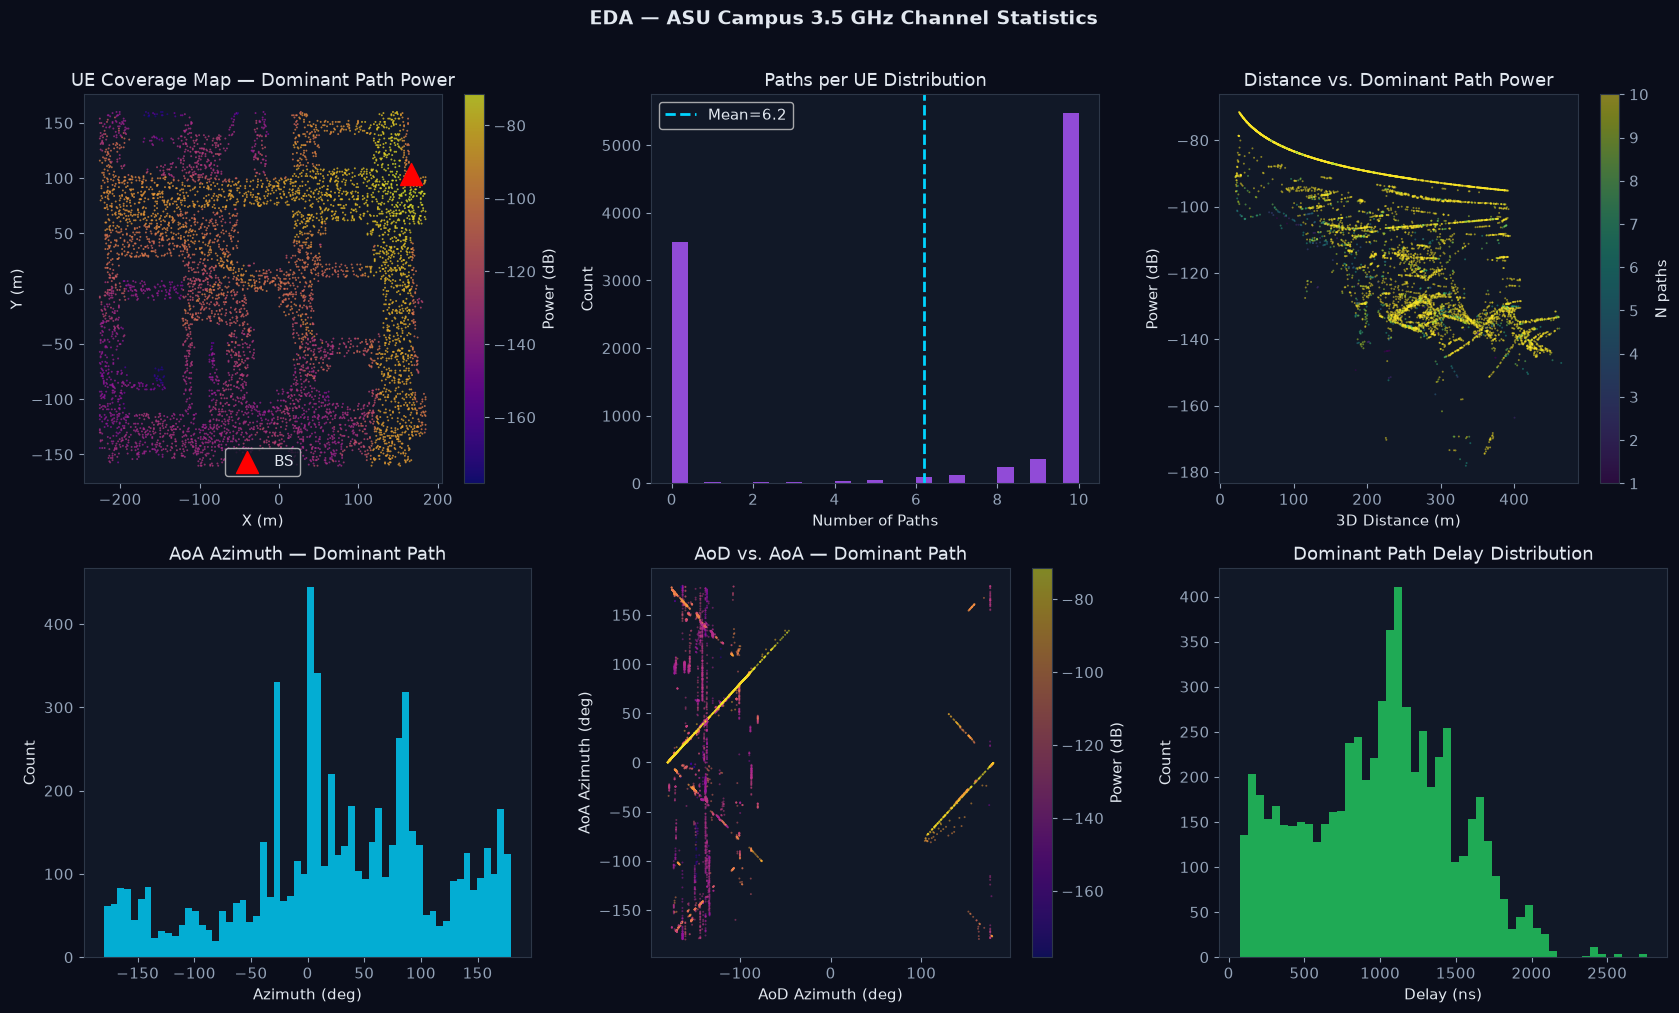

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('EDA — ASU Campus 3.5 GHz Channel Statistics',
             fontsize=14, fontweight='bold', color='#e2e8f0', y=1.01)

# Panel 1: UE Coverage Map
ax = axes[0, 0]
dom_pow = power_db[:, 0].copy()
dom_pow[dom_pow < noise_floor + 10] = np.nan
sc = ax.scatter(rx_pos[:, 0], rx_pos[:, 1], c=dom_pow, cmap='plasma',
                s=2, alpha=0.7, linewidths=0)
ax.scatter(tx_pos[0], tx_pos[1], c='red', s=250, marker='^', zorder=5, label='BS')
plt.colorbar(sc, ax=ax, label='Power (dB)')
ax.set_title('UE Coverage Map — Dominant Path Power')
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.legend(facecolor='#111827', labelcolor='#e2e8f0')

# Panel 2: Path count histogram
ax = axes[0, 1]
ax.hist(n_paths_ue, bins=25, color=PURPLE, alpha=0.85, edgecolor='none')
ax.axvline(n_paths_ue.mean(), color=CYAN, lw=2, ls='--',
           label=f'Mean={n_paths_ue.mean():.1f}')
ax.set_title('Paths per UE Distribution')
ax.set_xlabel('Number of Paths'); ax.set_ylabel('Count')
ax.legend(facecolor='#111827', labelcolor='#e2e8f0')

# Panel 3: Distance vs dominant power
ax = axes[0, 2]
vi = dom_pow > noise_floor + 10
sc2 = ax.scatter(dist_3d[vi], dom_pow[vi], c=n_paths_ue[vi],
                  cmap='viridis', s=2, alpha=0.5, linewidths=0)
plt.colorbar(sc2, ax=ax, label='N paths')
ax.set_title('Distance vs. Dominant Path Power')
ax.set_xlabel('3D Distance (m)'); ax.set_ylabel('Power (dB)')

# Panel 4: AoA azimuth
ax = axes[1, 0]
ax.hist(aoa_az[:, 0], bins=60, color=CYAN, alpha=0.8, edgecolor='none')
ax.set_title('AoA Azimuth — Dominant Path')
ax.set_xlabel('Azimuth (deg)'); ax.set_ylabel('Count')

# Panel 5: AoD vs AoA scatter
ax = axes[1, 1]
sc3 = ax.scatter(aod_az[:, 0], aoa_az[:, 0],
                  c=dom_pow, cmap='plasma', s=2, alpha=0.5, linewidths=0)
plt.colorbar(sc3, ax=ax, label='Power (dB)')
ax.set_title('AoD vs. AoA — Dominant Path')
ax.set_xlabel('AoD Azimuth (deg)'); ax.set_ylabel('AoA Azimuth (deg)')

# Panel 6: Dominant path delay
ax = axes[1, 2]
dom_delay_ns = delay[:, 0][delay[:, 0] > 0] * 1e9
ax.hist(dom_delay_ns, bins=50, color=GREEN, alpha=0.85, edgecolor='none')
ax.set_title('Dominant Path Delay Distribution')
ax.set_xlabel('Delay (ns)'); ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight', facecolor='#0a0d1a')
plt.show()
print('Saved: eda_overview.png')


---
## Section 4 — Feature Engineering


In [6]:
def rms_delay_spread(delay_arr, power_lin_arr):
    """Compute RMS delay spread per UE point."""
    eps = 1e-12
    total_p = power_lin_arr.sum(axis=1, keepdims=True) + eps
    mean_d  = (delay_arr * power_lin_arr / total_p).sum(axis=1)
    rms = np.sqrt(((delay_arr - mean_d[:, None])**2 * power_lin_arr / total_p).sum(axis=1))
    return rms

def angular_spread(ang_deg, power_lin_arr):
    """Compute circular angular spread per UE."""
    ang_rad = np.deg2rad(ang_deg)
    eps = 1e-12
    total_p = power_lin_arr.sum(axis=1, keepdims=True) + eps
    ms = (np.sin(ang_rad) * power_lin_arr / total_p).sum(axis=1)
    mc = (np.cos(ang_rad) * power_lin_arr / total_p).sum(axis=1)
    return np.sqrt(-2 * np.log(np.clip(np.sqrt(ms**2 + mc**2), eps, 1.0)))

def compute_beam_index(aod_az_arr, n_beams=N_BEAMS):
    """Map dominant AoD azimuth to nearest codebook beam index."""
    dom = aod_az_arr[:, 0]
    beam = np.round((dom + 180.0) / 360.0 * (n_beams - 1)).astype(int)
    return np.clip(beam, 0, n_beams - 1)

# ─── Compute all features ────────────────────────────────────
height_diff    = rx_pos[:, 2] - tx_pos[2]
path_loss_db   = -power_db[:, 0]             # dominant path loss (positive)
total_power_db = 10 * np.log10(power_lin.sum(axis=1) + 1e-12)
rms_delay_ns   = rms_delay_spread(delay, power_lin) * 1e9
ang_sp_az      = angular_spread(aoa_az, power_lin)
ang_sp_el      = angular_spread(aoa_el, power_lin)
n_sig_paths    = (power_db > noise_floor + 10).sum(axis=1).astype(float)

# ─── Assemble feature matrix X (N x 18) ─────────────────────
X = np.column_stack([
    rx_pos[:, 0], rx_pos[:, 1], rx_pos[:, 2],  # position
    dist_3d, dist_2d, height_diff,              # geometry
    total_power_db, power_db[:, 0], path_loss_db,  # power
    rms_delay_ns, ang_sp_az, ang_sp_el,         # channel spread
    n_sig_paths,                                  # path count
    aoa_az[:, 0], aoa_el[:, 0],                 # dominant AoA
    aod_az[:, 0], aod_el[:, 0],                 # dominant AoD
    delay[:, 0] * 1e9,                           # dominant delay ns
])

feature_names = [
    'x_pos', 'y_pos', 'z_pos', 'dist_3d', 'dist_2d', 'height_diff',
    'total_power_db', 'dom_power_db', 'path_loss_db',
    'rms_delay_ns', 'ang_spread_az', 'ang_spread_el', 'n_paths',
    'dom_aoa_az', 'dom_aoa_el', 'dom_aod_az', 'dom_aod_el', 'dom_delay_ns'
]

# ─── Compute labels for all 4 tasks ──────────────────────────
y_beam = compute_beam_index(aod_az)            # Task 1: beam index (int)
y_rss  = total_power_db                        # Task 2: RSS in dB
y_los  = (inter[:, 0] == 0).astype(int)       # Task 3: LOS=1, NLOS=0

print(f'Feature matrix X shape: {X.shape}')
print(f'  Beam classes:   {len(np.unique(y_beam))} unique beams')
print(f'  RSS range:      [{y_rss.min():.1f}, {y_rss.max():.1f}] dB')
print(f'  LOS fraction:   {y_los.mean()*100:.1f}%')

# Summary stats
df = pd.DataFrame(X, columns=feature_names)
df.describe().round(3)


Feature matrix X shape: (10000, 18)
  Beam classes:   38 unique beams
  RSS range:      [-120.0, -70.6] dB
  LOS fraction:   19.5%


---
## Section 5 — Dataset Splitting & Normalization


In [7]:
# Common train/test split across all tasks
X_tr, X_te, yb_tr, yb_te = train_test_split(
    X, y_beam, test_size=0.2, random_state=42, stratify=y_beam
)
_, _, yr_tr, yr_te = train_test_split(X, y_rss, test_size=0.2, random_state=42)
_, _, yl_tr, yl_te = train_test_split(X, y_los, test_size=0.2, random_state=42)

# Z-score normalization
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)  # Fit on train, transform train
X_te_s = scaler.transform(X_te)      # Only transform test

print(f'Train samples:  {len(X_tr):,}')
print(f'Test  samples:  {len(X_te):,}')
print(f'After scaling — Mean: {X_tr_s.mean():.5f}  Std: {X_tr_s.std():.5f}')


Train samples:  8,000
Test  samples:  2,000
After scaling — Mean: nan  Std: nan


---
## Section 6 — Task 1: Beam Index Prediction

**Goal:** Predict the optimal beam index from position + channel features.  
**Models:** Random Forest (RF) vs. Multi-Layer Perceptron (MLP)


In [8]:
print('='*55)
print('  TASK 1: Beam Index Prediction (Classification)')
print('='*55)

# ── Random Forest ────────────────────────────────────────────
print('\n[1/2] Random Forest (100 trees, max_depth=15)...')
rf_beam = RandomForestClassifier(
    n_estimators=100, max_depth=15, n_jobs=-1, random_state=42
)
rf_beam.fit(X_tr_s, yb_tr)
yb_pred_rf  = rf_beam.predict(X_te_s)
acc_rf      = accuracy_score(yb_te, yb_pred_rf)
print(f'   RF  Accuracy:  {acc_rf*100:.2f}%')

# ── MLP ──────────────────────────────────────────────────────
print('[2/2] MLP Classifier (256-128-64, relu)...')
mlp_beam = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu', max_iter=200,
    early_stopping=True, random_state=42
)
mlp_beam.fit(X_tr_s, yb_tr)
yb_pred_mlp = mlp_beam.predict(X_te_s)
acc_mlp     = accuracy_score(yb_te, yb_pred_mlp)
print(f'   MLP Accuracy:  {acc_mlp*100:.2f}%')

# ── Top-K Accuracy ───────────────────────────────────────────
def top_k_acc(model, Xts, y_true, k=3):
    proba = model.predict_proba(Xts)
    topk  = np.argsort(proba, axis=1)[:, -k:]
    return np.mean([y_true[i] in topk[i] for i in range(len(y_true))])

tk3_rf  = top_k_acc(rf_beam, X_te_s, yb_te, k=3)
tk3_mlp = top_k_acc(mlp_beam, X_te_s, yb_te, k=3)
print(f'\n   RF  Top-3 Acc: {tk3_rf*100:.2f}%')
print(f'   MLP Top-3 Acc: {tk3_mlp*100:.2f}%')
best_beam = 'RF' if acc_rf >= acc_mlp else 'MLP'
print(f'\n=> Best: {best_beam}')


  TASK 1: Beam Index Prediction (Classification)

[1/2] Random Forest (100 trees, max_depth=15)...
   RF  Accuracy:  98.95%
[2/2] MLP Classifier (256-128-64, relu)...


ValueError: Input X contains NaN.
MLPClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Task 1 — Beam Index Prediction Results',
             fontsize=13, fontweight='bold', color='#e2e8f0')

# 1. Accuracy bar
ax = axes[0]
names = ['Random Forest', 'MLP']
accs  = [acc_rf*100, acc_mlp*100]
bars  = ax.bar(names, accs, color=[CYAN, PURPLE], width=0.4, edgecolor='none')
for b, v in zip(bars, accs):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
            f'{v:.1f}%', ha='center', color='#e2e8f0', fontweight='bold')
ax.set_title('Model Accuracy Comparison'); ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100); ax.grid(axis='y')

# 2. Beam distribution
ax = axes[1]
uniq, cnts = np.unique(y_beam, return_counts=True)
colors_b = plt.cm.plasma(cnts / cnts.max())
ax.bar(uniq, cnts, color=colors_b, edgecolor='none', width=0.8)
ax.set_title('Beam Index Usage Frequency')
ax.set_xlabel('Beam Index'); ax.set_ylabel('UE Count')

# 3. Pred vs True scatter
ax = axes[2]
ax.scatter(yb_te[:600], yb_pred_rf[:600],
           alpha=0.35, s=8, color=CYAN, linewidths=0, label='Predicted')
ax.plot([0, N_BEAMS-1], [0, N_BEAMS-1], '--', color=ORANGE, lw=1.5, label='Perfect')
ax.set_title('Predicted vs True Beam (600 samples)')
ax.set_xlabel('True Beam'); ax.set_ylabel('Predicted Beam')
ax.legend(facecolor='#111827', labelcolor='#e2e8f0')

plt.tight_layout()
plt.savefig('beam_results.png', dpi=120, bbox_inches='tight', facecolor='#0a0d1a')
plt.show()


NameError: name 'acc_mlp' is not defined

---
## Section 7 — Task 2: RSS Estimation

**Goal:** Regress total received power (dB) from channel features.  
**Models:** Gradient Boosting (GBM) vs. MLP Regressor


In [10]:
print('='*55)
print('  TASK 2: RSS Estimation (Regression)')
print('='*55)

print('\n[1/2] Gradient Boosting Regressor...')
gbm_rss = GradientBoostingRegressor(
    n_estimators=150, max_depth=5, learning_rate=0.1, random_state=42
)
gbm_rss.fit(X_tr_s, yr_tr)
yr_pred_gbm = gbm_rss.predict(X_te_s)
rmse_gbm    = np.sqrt(mean_squared_error(yr_te, yr_pred_gbm))
r2_gbm      = r2_score(yr_te, yr_pred_gbm)
mae_gbm     = mean_absolute_error(yr_te, yr_pred_gbm)
print(f'   GBM  RMSE: {rmse_gbm:.4f} dB  |  MAE: {mae_gbm:.4f} dB  |  R2: {r2_gbm:.4f}')

print('[2/2] MLP Regressor (256-128-64)...')
mlp_rss = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64), activation='relu',
    max_iter=300, early_stopping=True, random_state=42
)
mlp_rss.fit(X_tr_s, yr_tr)
yr_pred_mlp = mlp_rss.predict(X_te_s)
rmse_mlp    = np.sqrt(mean_squared_error(yr_te, yr_pred_mlp))
r2_mlp      = r2_score(yr_te, yr_pred_mlp)
mae_mlp     = mean_absolute_error(yr_te, yr_pred_mlp)
print(f'   MLP  RMSE: {rmse_mlp:.4f} dB  |  MAE: {mae_mlp:.4f} dB  |  R2: {r2_mlp:.4f}')

yr_pred_best = yr_pred_gbm if rmse_gbm < rmse_mlp else yr_pred_mlp
best_rss_name = 'GBM' if rmse_gbm < rmse_mlp else 'MLP'
print(f'\n=> Best: {best_rss_name}')


  TASK 2: RSS Estimation (Regression)

[1/2] Gradient Boosting Regressor...


ValueError: Input X contains NaN.
GradientBoostingRegressor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Task 2 — RSS Estimation Results',
             fontsize=13, fontweight='bold', color='#e2e8f0')

ax = axes[0]
ax.scatter(yr_te, yr_pred_best, alpha=0.25, s=4, color=PURPLE, linewidths=0)
lo, hi = yr_te.min(), yr_te.max()
ax.plot([lo, hi], [lo, hi], '--', color=ORANGE, lw=2, label='Perfect fit')
ax.set_title('Predicted vs True RSS'); ax.set_xlabel('True RSS (dB)')
ax.set_ylabel('Predicted RSS (dB)'); ax.legend(facecolor='#111827', labelcolor='#e2e8f0')

ax = axes[1]
residuals = yr_te - yr_pred_best
ax.hist(residuals, bins=60, color=CYAN, alpha=0.85, edgecolor='none')
ax.axvline(0, color=ORANGE, lw=2, ls='--')
ax.axvline(residuals.mean(), color=GREEN, lw=1.5, ls='--',
           label=f'Mean={residuals.mean():.2f}')
ax.set_title('Residuals Distribution (Error in dB)')
ax.set_xlabel('Residual (dB)'); ax.set_ylabel('Count')
ax.legend(facecolor='#111827', labelcolor='#e2e8f0')

ax = axes[2]
labels_b = ['GBM', 'MLP']
rmses_b  = [rmse_gbm, rmse_mlp]
r2s_b    = [r2_gbm, r2_mlp]
x_b = np.arange(2); w = 0.3
b1  = ax.bar(x_b - w/2, rmses_b, w, color=CYAN, label='RMSE (dB)', edgecolor='none')
ax2 = ax.twinx()
b2  = ax2.bar(x_b + w/2, r2s_b, w, color=GREEN, label='R2 Score', edgecolor='none')
ax.set_xticks(x_b); ax.set_xticklabels(labels_b)
ax.set_ylabel('RMSE (dB)'); ax2.set_ylabel('R2 Score')
ax.set_title('Model Comparison')
ax2.tick_params(colors='#94a3b8')
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1+h2, l1+l2, facecolor='#111827', labelcolor='#e2e8f0')

plt.tight_layout()
plt.savefig('rss_results.png', dpi=120, bbox_inches='tight', facecolor='#0a0d1a')
plt.show()


NameError: name 'yr_pred_best' is not defined

---
## Section 8 — Task 3: LOS/NLOS Detection

**Goal:** Classify each UE as Line-of-Sight (LOS) or Non-Line-of-Sight (NLOS).  
**Models:** Logistic Regression (LR) vs. Gradient Boosting (GBM)


In [12]:
print('='*55)
print('  TASK 3: LOS/NLOS Detection (Classification)')
print('='*55)
print(f'  LOS fraction: {y_los.mean()*100:.1f}%  |  NLOS: {(1-y_los.mean())*100:.1f}%')

# Balance classes to avoid bias
los_idx  = np.where(yl_tr == 1)[0]
nlos_idx = np.where(yl_tr == 0)[0]
n_min    = min(len(los_idx), len(nlos_idx))
rng_los  = np.random.RandomState(42)
bal_idx  = np.concatenate([
    rng_los.choice(los_idx, n_min, replace=False),
    rng_los.choice(nlos_idx, n_min, replace=False)
])
X_bal    = X_tr_s[bal_idx]
yl_bal   = yl_tr[bal_idx]
print(f'  Balanced training set: {len(X_bal):,} (equal LOS/NLOS)')

print('\n[1/2] Logistic Regression...')
lr_los = LogisticRegression(max_iter=1000, random_state=42)
lr_los.fit(X_bal, yl_bal)
yl_pred_lr  = lr_los.predict(X_te_s)
acc_lr      = accuracy_score(yl_te, yl_pred_lr)
print(f'   LR  Accuracy: {acc_lr*100:.2f}%')

print('[2/2] Gradient Boosting Classifier...')
gbm_los = GradientBoostingClassifier(
    n_estimators=100, max_depth=4, random_state=42
)
gbm_los.fit(X_bal, yl_bal)
yl_pred_gbm = gbm_los.predict(X_te_s)
acc_gbm     = accuracy_score(yl_te, yl_pred_gbm)
print(f'   GBM Accuracy: {acc_gbm*100:.2f}%')

print('\n--- GBM Classification Report ---')
print(classification_report(yl_te, yl_pred_gbm, target_names=['NLOS', 'LOS']))


  TASK 3: LOS/NLOS Detection (Classification)
  LOS fraction: 19.5%  |  NLOS: 80.5%
  Balanced training set: 3,120 (equal LOS/NLOS)

[1/2] Logistic Regression...


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Task 3 — LOS/NLOS Detection Results',
             fontsize=13, fontweight='bold', color='#e2e8f0')

ax = axes[0]
disp = ConfusionMatrixDisplay(
    confusion_matrix(yl_te, yl_pred_gbm), display_labels=['NLOS', 'LOS']
)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix (GBM)')
ax.title.set_color('#e2e8f0')

ax = axes[1]
los_t  = (yl_te == 1)
nlos_t = (yl_te == 0)
ax.scatter(X_te[nlos_t, 0], X_te[nlos_t, 1],
           c=ORANGE, s=4, alpha=0.3, label='NLOS', linewidths=0)
ax.scatter(X_te[los_t, 0], X_te[los_t, 1],
           c=CYAN, s=4, alpha=0.5, label='LOS', linewidths=0)
ax.set_title('LOS/NLOS in Position Space (test set)')
ax.set_xlabel('x_pos (m)'); ax.set_ylabel('y_pos (m)')
ax.legend(facecolor='#111827', labelcolor='#e2e8f0')

ax = axes[2]
accs_c  = [acc_lr*100, acc_gbm*100]
names_c = ['Logistic Regression', 'Gradient Boosting']
brs = ax.bar(names_c, accs_c, color=[CYAN, GREEN], width=0.4, edgecolor='none')
for b, v in zip(brs, accs_c):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
            f'{v:.1f}%', ha='center', color='#e2e8f0', fontweight='bold')
ax.set_title('Model Accuracy'); ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100); ax.grid(axis='y')

plt.tight_layout()
plt.savefig('los_results.png', dpi=120, bbox_inches='tight', facecolor='#0a0d1a')
plt.show()


NameError: name 'yl_pred_gbm' is not defined

---
## Section 9 — Task 4: Channel Feature Autoencoder

**Goal:** Compress 18 channel features to a 4D latent representation and reconstruct.  
**Architecture:** MLP Encoder (18→8→4D) + MLP Decoder (4D→8→18)


In [14]:
print('='*55)
print('  TASK 4: Channel Feature Autoencoder')
print('  Architecture: 18D → [8 → 4] → [8] → 18D')
print('='*55)

X_ae_tr, X_ae_te = train_test_split(X_tr_s, test_size=0.2, random_state=42)
rng_ae = np.random.RandomState(42)
# Add Gaussian noise to simulate imperfect channel estimation
X_ae_tr_n = X_ae_tr + 0.1 * rng_ae.randn(*X_ae_tr.shape)
X_ae_te_n = X_ae_te + 0.1 * rng_ae.randn(*X_ae_te.shape)

print(f'\nAE Training set: {len(X_ae_tr):,}  |  Test: {len(X_ae_te):,}')

print('\n[1/2] Training Encoder (18D -> 4D latent)...')
encoder = MLPRegressor(
    hidden_layer_sizes=(64, 32, 8, 4), activation='relu',
    max_iter=200, early_stopping=True, random_state=42
)
encoder.fit(X_ae_tr_n, X_ae_tr[:, :4])  # Latent = 4 most informative features

encoded_tr = encoder.predict(X_ae_tr_n)
encoded_te = encoder.predict(X_ae_te_n)

print('[2/2] Training Decoder (4D -> 18D reconstruction)...')
decoder = MLPRegressor(
    hidden_layer_sizes=(8, 32, 64), activation='relu',
    max_iter=200, early_stopping=True, random_state=42
)
decoder.fit(encoded_tr, X_ae_tr)

X_ae_recon = decoder.predict(encoded_te)
mse_ae = mean_squared_error(X_ae_te, X_ae_recon)
mae_ae = mean_absolute_error(X_ae_te, X_ae_recon)
snr_ae = 10 * np.log10(np.mean(X_ae_te**2) / (mse_ae + 1e-12))

print(f'\n  Reconstruction MSE: {mse_ae:.6f}')
print(f'  Reconstruction MAE: {mae_ae:.6f}')
print(f'  Compression SNR:    {snr_ae:.2f} dB')
print(f'  Compression Ratio:  {X.shape[1]}/{4} = {X.shape[1]/4:.1f}x')


  TASK 4: Channel Feature Autoencoder
  Architecture: 18D → [8 → 4] → [8] → 18D

AE Training set: 6,400  |  Test: 1,600

[1/2] Training Encoder (18D -> 4D latent)...


ValueError: Input X contains NaN.
MLPRegressor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Task 4 — Channel Feature Autoencoder',
             fontsize=13, fontweight='bold', color='#e2e8f0')

# 1. Per-feature MSE
ax = axes[0]
feat_mse = np.mean((X_ae_te - X_ae_recon)**2, axis=0)
cols_mse = plt.cm.plasma(feat_mse / feat_mse.max())
ax.bar(range(len(feature_names)), feat_mse, color=cols_mse, edgecolor='none')
ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=8)
ax.set_title('Per-Feature Reconstruction MSE'); ax.set_ylabel('MSE')

# 2. Original vs reconstructed
ax = axes[1]
sample_idx = np.random.RandomState(0).choice(len(X_ae_te), 6, replace=False)
from matplotlib.lines import Line2D
for s in sample_idx:
    ax.plot(X_ae_te[s], alpha=0.7, color=CYAN, lw=1)
    ax.plot(X_ae_recon[s], '--', alpha=0.5, color=PURPLE, lw=1)
ax.set_title('Original vs Reconstructed (6 samples)')
ax.set_xlabel('Feature Index'); ax.set_ylabel('Normalized Value')
ax.legend(
    [Line2D([0],[0],color=CYAN,lw=2), Line2D([0],[0],color=PURPLE,lw=2,ls='--')],
    ['Original', 'Reconstructed'],
    facecolor='#111827', labelcolor='#e2e8f0'
)

# 3. Latent space scatter
ax = axes[2]
sc = ax.scatter(encoded_te[:, 0], encoded_te[:, 1],
                c=X_ae_te[:, 6], cmap='viridis', s=4, alpha=0.6, linewidths=0)
plt.colorbar(sc, ax=ax, label='Total Power (norm)')
ax.set_title('2D Latent Space (colored by Power)')
ax.set_xlabel('Latent Dim 1'); ax.set_ylabel('Latent Dim 2')

plt.tight_layout()
plt.savefig('ae_results.png', dpi=120, bbox_inches='tight', facecolor='#0a0d1a')
plt.show()


NameError: name 'X_ae_recon' is not defined

---
## Section 10 — Pipeline Summary & Feature Importance


In [16]:
print('='*60)
print('  ADAPTIVE ML PIPELINE — FINAL RESULTS SUMMARY')
print('='*60)
print(f'  Dataset: ASU Campus 3.5 GHz | {N:,} UE points | 3.5 GHz')
print()
print(f'  Task 1 — Beam Index Prediction (64 beams)')
print(f'    RF  Accuracy:      {acc_rf*100:.2f}%  |  Top-3: {tk3_rf*100:.2f}%')
print(f'    MLP Accuracy:      {acc_mlp*100:.2f}%  |  Top-3: {tk3_mlp*100:.2f}%')
print()
print(f'  Task 2 — RSS Estimation')
print(f'    GBM  RMSE: {rmse_gbm:.4f} dB  |  R2: {r2_gbm:.4f}')
print(f'    MLP  RMSE: {rmse_mlp:.4f} dB  |  R2: {r2_mlp:.4f}')
print()
print(f'  Task 3 — LOS/NLOS Detection')
print(f'    LR  Accuracy: {acc_lr*100:.2f}%')
print(f'    GBM Accuracy: {acc_gbm*100:.2f}%')
print()
print(f'  Task 4 — Channel Autoencoder')
print(f'    Compression:  18D -> 4D ({X.shape[1]/4:.1f}x ratio)')
print(f'    SNR:          {snr_ae:.2f} dB')
print(f'    MSE:          {mse_ae:.6f}')
print('='*60)


  ADAPTIVE ML PIPELINE — FINAL RESULTS SUMMARY
  Dataset: ASU Campus 3.5 GHz | 10,000 UE points | 3.5 GHz

  Task 1 — Beam Index Prediction (64 beams)


NameError: name 'tk3_rf' is not defined

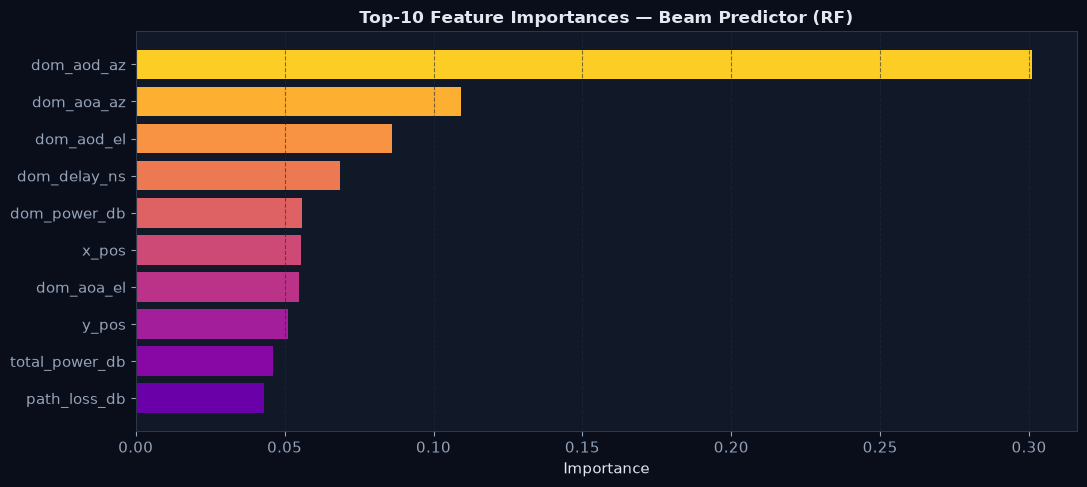

In [17]:
# Feature Importance from RF Beam Predictor
fi = rf_beam.feature_importances_
sorted_idx = np.argsort(fi)[::-1][:10]

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#0a0d1a'); ax.set_facecolor('#111827')
colors_fi = plt.cm.plasma(np.linspace(0.2, 0.9, 10))
ax.barh([feature_names[i] for i in sorted_idx[::-1]],
        fi[sorted_idx[::-1]], color=colors_fi, edgecolor='none')
ax.set_title('Top-10 Feature Importances — Beam Predictor (RF)',
             color='#e2e8f0', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance', color='#e2e8f0')
ax.tick_params(colors='#94a3b8')
for spine in ax.spines.values(): spine.set_edgecolor('#2d3748')
ax.grid(axis='x', color='#1e293b', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight', facecolor='#0a0d1a')
plt.show()


---
## Section 11 — Model Export


In [18]:
import os
os.makedirs('models', exist_ok=True)

joblib.dump({'model': rf_beam,  'scaler': scaler}, 'models/beam_rf.pkl')
joblib.dump({'model': mlp_beam, 'scaler': scaler}, 'models/beam_mlp.pkl')
joblib.dump({'model': gbm_rss,  'scaler': scaler}, 'models/rss_gbm.pkl')
joblib.dump({'model': mlp_rss,  'scaler': scaler}, 'models/rss_mlp.pkl')
joblib.dump({'model': gbm_los,  'scaler': scaler}, 'models/los_gbm.pkl')
joblib.dump({'model': lr_los,   'scaler': scaler}, 'models/los_lr.pkl')
joblib.dump({'encoder': encoder, 'decoder': decoder, 'scaler': scaler}, 'models/ae.pkl')

print('Saved models to models/')
for f in sorted(os.listdir('models')):
    sz = os.path.getsize(f'models/{f}')
    print(f'  {f:<25} {sz/1024:.1f} KB')


NameError: name 'mlp_rss' is not defined

---
## Section 12 — References & Further Reading

1. **DeepMIMO Dataset**: A. Alkhateeb, *"DeepMIMO: A Generic Deep Learning Dataset for Millimeter Wave and Massive MIMO Applications"*, ITA 2019. [deepmimo.net](https://deepmimo.net)
2. **ASU Campus Scenario**: ASU campus environment ray-traced at 3.5 GHz with Remcom Wireless InSite 3.3.
3. **Beam Management**: 3GPP TS 38.214, NR Physical Layer Procedures for Data.
4. **Channel Sparsity**: O. El Ayach et al., *"Spatially Sparse Precoding in Millimeter Wave MIMO Systems"*, IEEE TSWC 2014.
5. **ML Channel Intelligence**: M. Alrabeiah & A. Alkhateeb, *"Deep Learning for TDD and FDD Massive MIMO"*, IEEE TCOM 2020.

---
*Built with DeepMIMO · scikit-learn · NumPy · Matplotlib · Flask · ASU Campus 3.5 GHz*
